Давайте подивимося, як LSTM можна використовувати для побудови нейронної мережі прогнозування часових.

Будемо працювати з задачею прогнозування кількості пасажирів міжнародних авіаліній. З цим набором даних ми вже працювали в лекції "Time Series Analysis" і ви зможете порівняти результати :)

Задача полягає в тому, щоб за заданими роком і місяцем передбачити кількість пасажирів міжнародних авіаліній в одиницях виміру 1,000. Дані охоплюють період з січня 1949 року по грудень 1960 року, тобто 12 років, зі 144 спостереженнями.

Це регресійна задача. Тобто, знаючи кількість пасажирів (в тисячах) за останні місяці, можна передбачити, якою буде кількість пасажирів у наступному місяці. Набір даних має лише одну характеристику: "Кількість пасажирів" - `Passengers`.

Далі вже наведений код для читання даних, але нам їх ще треба буде трошки обробити.

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

# Завантаження даних
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
df = pd.read_csv(url)
df.set_index('Month', inplace=True)
display(df.head())

,Passengers
Month,
1949-01,112
1949-02,118
1949-03,132
1949-04,129
1949-05,121


**Завдання 1.** Створіть змінну типу `numpy.ndarray`, яка містить значення кількості пасажирів в форматі `float32`. Такий формат даних нам треба для тренування нейромережі.

In [2]:
from numpy import float32

passengers_np = df['Passengers'].to_numpy(dtype=float32)
passengers_np[:10]

array([112., 118., 132., 129., 121., 135., 148., 148., 136., 119.],
      dtype=float32)

Очікуваний результат:
```array([112., 118., 132., 129., 121.], dtype=float32)```

**Завдання 2**. Розбийте дані на тренувальні і валідаційні у співвідношенні 67% йде у тренування, 33 - у валідацію. Памʼятаємо, що ми працюємо з tim series, відповідно, навчаємось на давніших, валідуємось - на новіших.

In [3]:
# Розбиття на train / validation
train_size = int(len(passengers_np) * 0.67)

train_data = passengers_np[:train_size]
val_data = passengers_np[train_size:]

print(f"Train size: {len(train_data)}")
print(f"Validation size: {len(val_data)}")

Train size: 96
Validation size: 48


**Завдання 3**.

Реалізуйте функцію `create_dataset`, яка перетворить одномірний часовий ряд (набір даних) у формат, придатний для тренування нейромережі.

Функція повинна приймати два аргументи:
- `dataset` — numpy-масив часового ряду,
- `lookback` — кількість попередніх кроків, які використовуватимуться для передбачення.

Функція повинна повернути два **тензори** PyTorch:
- `X` — набір ознак (вікно попередніх значень),
- `y` — цільові значення (наступні після вікна кроки).

Дані ми будемо подавати моделі в наступному форматі:
`
tensor([[112.],
        [118.],
        [132.],
        [129.],
        [121.]])
`
Відповідно першою розмірністю буде йти розмір вхідного батча, а другою - розмір вхіднизх даних і в нас це 1, бо лише одне значення на вході щоразу.

Після виконання завдання запустіть код нижче. Ми будемо передбачати на основі кількості пасажирів в попередній день кількість пасажирів в наступний, тому `lookback == 1`.

In [4]:
import torch

def create_dataset(dataset, lookback=1):
    X, y = [], []

    # if total 100 and loopback 10 than i=90 will be last for X as there is no target at index 101  
    for i in range(len(dataset) - lookback):
        feature = dataset[i:i + lookback]
        target = dataset[i + lookback]

        X.append(feature)
        y.append(target)

    # Перетворення у тензори PyTorch
    X = torch.tensor(X, dtype=torch.float32).unsqueeze(-1)
    y = torch.tensor(y, dtype=torch.float32).unsqueeze(-1)

    return X, y

In [5]:
lookback = 1
X_train, y_train = create_dataset(train_data, lookback=lookback)
X_test, y_test = create_dataset(val_data, lookback=lookback)
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

torch.Size([95, 1, 1]) torch.Size([95, 1])
torch.Size([47, 1, 1]) torch.Size([47, 1])


/var/folders/0s/q_d47bvj0hq4rs_6q_06d63m0000gn/T/ipykernel_24542/3079652469.py:15: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:278.)
  X = torch.tensor(X, dtype=torch.float32).unsqueeze(-1)


Для RNN/LSTM у PyTorch вхід має формат: (batch_size, sequence_length, input_size)
- batch_size — кількість прикладів,
- sequence_length — довжина послідовності (lookback),
- input_size — кількість ознак на кожному кроці часу. 

lookback = 1 - на кожному кроці лише одна ознака — кількість пасажирів.

Очікуваний результат:
```
torch.Size([95, 1]) torch.Size([95, 1])
torch.Size([47, 1]) torch.Size([47, 1])
```

**Завдання 4**.

Зверніть увагу на розмірності в попередньому завданні. Ми
З допомогою модуля `torch.nn` опишіть клас `AirModel`, який є нейронною мережею для прогнозування кількості пасажирів за допомогою LSTM.

1. **Конструктор класу** повинен приймати параметри `hidden_size`, `num_layers` та ініціювати шари:
   - LSTM-шар з наступними параметрами:
     - `input_size` — кожна точка часового ряду є окремим входом,,
     - `hidden_size` — заданий в конструкторі класу мережі,
     - `num_layers=1` — кількість шарів LSTM, задана в конструкторі мережі,
     - `batch_first=True` — визначає, що першим виміром є розмір батчу.
   - Лінійний шар (`nn.Linear`) для перетворення виходу LSTM на прогноз однієї точки.

2. **Метод forward** повинен виконувати наступні дії:
   - Передати вхідний тензор через LSTM-шар і отримати виходи (ігноруючи приховані стани).
   - Пропустити вихід LSTM через лінійний шар для отримання остаточного прогнозу.

Створіть об'єкт класу `AirModel` зі значеннями параметрів `hidden_size=50`, `num_layers=1` і протестуйте роботу моделі на вхідному тензорі `tensor([[112.]])`. На цьому етапі ми маємо переконатись, що модель здатна генерувати передбачення з рандомно ініційованими вагами.

In [6]:
import torch
import torch.nn as nn

class AirModel(nn.Module):
    def __init__(self, hidden_size, num_layers):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=1,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )

        self.linear = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # lstm_out shape:
        # (batch_size, sequence_length, hidden_size)
        lstm_out, _ = self.lstm(x)

        # беремо всі елементи батчу, останній timestep, всі hidden_size ознаки
        output = self.linear(lstm_out[:, -1, :])

        return output


In [7]:
model = AirModel(hidden_size=50, num_layers=1)

In [8]:
x_smoke_test = torch.tensor([[[112.]]], dtype=torch.float32)

prediction_smoke = model(x_smoke_test)

print(prediction_smoke)
print(prediction_smoke.shape)

tensor([[0.1020]], grad_fn=<AddmmBackward0>)
torch.Size([1, 1])


**Завдання 5**.

Створіть об'єкт DataLoader для завантаження даних, використовуючи тренувальні вибірки `X_train` та `y_train`. Ваш DataLoader повинен виконувати наступні вимоги:

1. Використовувати клас `TensorDataset`, щоб об'єднати тензори ознак `X_train` і цільових значень `y_train`.
2. Дані повинні завантажуватися невеликими батчами розміром 8 за допомогою параметра `batch_size`.
3. Використовувати параметр `shuffle=True`, щоб дані перемішувалися перед кожною епохою тренування.


In [9]:
from torch.utils.data import TensorDataset, DataLoader

# Створення dataset
train_dataset = TensorDataset(X_train, y_train)

# DataLoader
train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True
)

In [10]:
# Перевірка одного батчу
for X_batch, y_batch in train_loader:
    print(X_batch.shape)
    print(y_batch.shape)
    break

torch.Size([8, 1, 1])
torch.Size([8, 1])


- 8 - розмір батчу,
- другий 1 - lookback,
- третій 1 - input_size

**Завдання 6**.

1. Реалізуйте навчання нейронної мережі `AirModel` для прогнозування часових рядів, використовуючи Adam-оптимізатор та функцію втрат MSE (середньоквадратичну похибку).
2. Створіть цикл тренування для 2000 епох, у якому на кожній епосі:
   - Виконуйте крок тренування моделі (прямий прохід, обчислення похибки, зворотний прохід і оновлення ваг).
   - Підраховуйте середню похибку на кожному батчі даних і зберігайте її у списку `losses`.
3. Раз на 100 епох проводьте валідацію моделі:
   - Перевіряйте модель на тренувальних та тестових даних без оновлення ваг.
   - Обчислюйте корінь середньоквадратичної похибки (RMSE) для тренувальної та тестової вибірок і виводьте результати на екран.
   
**Примітка:**
- Використовуйте вже створений `DataLoader` для отримання батчів даних.
- Валідацію виконуйте в режимі `eval()`, вимикаючи обчислення градієнтів з `torch.no_grad()`.

**Приклад виходу:**
```
Epoch 0: train RMSE 12.3456, test RMSE 15.6789
Epoch 100: train RMSE 9.8765, test RMSE 12.3456
...
```

In [11]:
model

AirModel(
  (lstm): LSTM(1, 50, batch_first=True)
  (linear): Linear(in_features=50, out_features=1, bias=True)
)

In [13]:
# loss function & optimizer
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# number of epochs
epochs = 2000

In [14]:
def train_model(model, criterion, optimizer, epochs):
    # список для збереження loss
    losses = []
    # training loop
    for epoch in range(epochs):

        # activate train mode
        model.train()

        epoch_losses = []

        for X_batch, y_batch in train_loader:

            # обнулення градієнтів
            optimizer.zero_grad()

            # forward pass
            predictions = model(X_batch)

            # loss
            loss = criterion(predictions, y_batch)

            # backward pass
            loss.backward()

            # update weights
            optimizer.step()

            epoch_losses.append(loss.item())

        # середній loss за епоху
        mean_loss = np.mean(epoch_losses)
        losses.append(mean_loss)

        # validation кожні 100 епох
        if epoch % 100 == 0:

            # activate validation mode
            model.eval()

            with torch.no_grad():

                # train predictions
                train_predictions = model(X_train)

                # test predictions
                val_predictions = model(X_test)

                # RMSE
                train_rmse = torch.sqrt(
                    criterion(train_predictions, y_train)
                ).item()

                val_rmse = torch.sqrt(
                    criterion(val_predictions, y_test)
                ).item()

            print(
                f"Epoch {epoch}: "
                f"train RMSE {train_rmse:.4f}, "
                f"test RMSE {val_rmse:.4f}"
            )
    
    return losses


In [15]:
losses = train_model(model, criterion, optimizer, epochs)

Epoch 0: train RMSE 225.8310, test RMSE 422.2326
Epoch 100: train RMSE 189.0342, test RMSE 383.7617
Epoch 200: train RMSE 156.5576, test RMSE 348.8874
Epoch 300: train RMSE 128.7563, test RMSE 317.6190
Epoch 400: train RMSE 105.4303, test RMSE 289.0824
Epoch 500: train RMSE 87.0145, test RMSE 263.4067
Epoch 600: train RMSE 70.6506, test RMSE 238.8534
Epoch 700: train RMSE 57.3859, test RMSE 215.9580
Epoch 800: train RMSE 47.3128, test RMSE 195.3261
Epoch 900: train RMSE 39.8131, test RMSE 176.8724
Epoch 1000: train RMSE 33.8989, test RMSE 160.5469
Epoch 1100: train RMSE 30.5643, test RMSE 146.9610
Epoch 1200: train RMSE 27.6940, test RMSE 135.6047
Epoch 1300: train RMSE 26.1716, test RMSE 126.7351
Epoch 1400: train RMSE 25.1536, test RMSE 119.5421
Epoch 1500: train RMSE 25.2224, test RMSE 115.2420
Epoch 1600: train RMSE 24.1530, test RMSE 109.4667
Epoch 1700: train RMSE 24.5402, test RMSE 106.3557
Epoch 1800: train RMSE 23.6482, test RMSE 102.6717
Epoch 1900: train RMSE 23.4792, test R

**Завдання 7.** Побудуйте графік лосів. Зробіть висновок з графіку, чи навчилась модель?

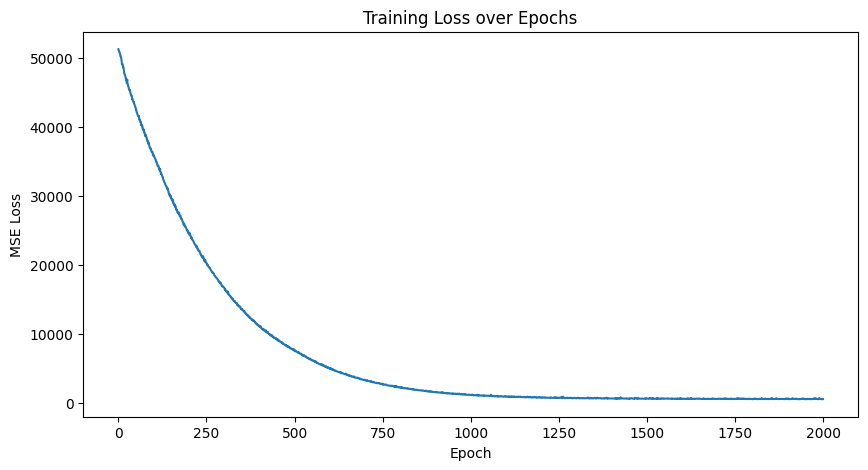

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(losses)
plt.title("Training Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.show()

Модель навчилась, але не факт, що точно)

Доволі неочікувано, що середньоквадратичне відхилення тестового набору даних буде на порядок більшим за одиниці в нашому наборі даних. Середньоквадратичне відхилення 100 означає, що прогноз і фактичне значення будуть відрізнятися в середньому на 100 (тобто, 100 000 пасажирів у цьому наборі даних).



Щоб краще зрозуміти якість прогнозу, ви можете побудувати графік з кодом нижче (а ще нижче - описано, що відбувається в цьому коді, бо це теж корисно зрозуміти):

In [17]:
np.ones_like(passengers_np) * np.nan

array([nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan], dtype=float32)

In [18]:
model(X_train)[:, -1].shape

torch.Size([95])

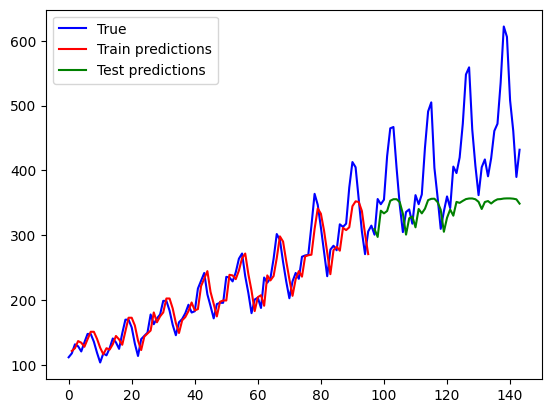

In [19]:
def plot_predicts(timeseries, model=model):
  with torch.no_grad():
      # Зсув прогнозів для тренувальних даних
      train_plot = np.ones_like(timeseries) * np.nan
      # y_pred = model(X_train)
      # y_pred = y_pred[:, -1]
      train_plot[lookback:train_size] = model(X_train)[:, -1]

      # Зсув прогнозів для тестових даних
      test_plot = np.ones_like(timeseries) * np.nan
      test_plot[train_size+lookback:len(timeseries)] = model(X_test)[:, -1]

  # Візуалізація результатів
  plt.plot(timeseries, c='b', label="True")  # Реальні дані
  plt.plot(train_plot, c='r', label="Train predictions")  # Прогнози на тренувальних даних
  plt.plot(test_plot, c='g', label="Test predictions")   # Прогнози на тестових даних
  plt.legend()
  plt.show()

plot_predicts(passengers_np)

**Що відбувається в коді вище.** В цьому коді здійснюється процес прогнозування часових рядів за допомогою LSTM моделі, а також виведення графіку, який показує реальні значення, тренувальні та тестові прогнози. Ось що відбувається на кожному етапі:

1. **`torch.no_grad()`**: Цей контекстний менеджер вимикає обчислення градієнтів, що означає, що під час прогнозування не будуть зберігатися проміжні обчислення для зворотного проходу (backpropagation). Це підвищує ефективність під час прогнозування і зменшує використання пам'яті.

2. **Зсув прогнозів для тренувальних даних:**
   - Створюється масив `train_plot`, який має такий самий розмір, як і часовий ряд (`timeseries`), і заповнюється значеннями NaN (`np.nan`), щоб залишити місце для реальних значень.
   - Модель передбачає виходи для тренувальних даних `X_train`.
   - Використовується лише останнє передбачене значення для кожного входу LSTM (`y_pred[:, -1]`).
   - Прогнози зсуваються, починаючи з індексу `lookback` до кінця тренувальних даних (індекс `train_size`). Цей зсув потрібен, щоб зробити прогноз на основі попередніх даних і відобразити його на правильній частині графіку.

3. **Зсув прогнозів для тестових даних:**
   - Створюється масив `test_plot`, який також заповнюється NaN.
   - Прогнози для тестових даних додаються з індексу `train_size + lookback` до кінця реальних даних, щоб відобразити, де модель починає прогнозувати тестову вибірку.

4. **Побудова графіка:**
   - `plt.plot(timeseries, c='b')`: Виводить реальні значення часового ряду (синя лінія).
   - `plt.plot(train_plot, c='r')`: Виводить тренувальні прогнози (червона лінія).
   - `plt.plot(test_plot, c='g')`: Виводить тестові прогнози (зелена лінія).

**Чому це робиться:**
- Зсув прогнозів для тренувальних і тестових даних дозволяє візуально зрівняти, наскільки добре модель прогнозує як на тренувальній, так і на тестовій вибірках. Зазвичай, червона лінія (тренувальні прогнози) повинна точно відповідати синій лінії (реальні дані), а зелена лінія (тестові прогнози) дає змогу побачити, наскільки модель добре працює на нових даних, яких вона раніше не бачила.

**Завдання 8**. Навчіть модель з hidden_size=100 та порівняйте результати прогнозів з попередніми.

In [20]:
# new model
model_100 = AirModel(hidden_size=100, num_layers=1)

In [21]:
# brand new Loss and optimizer
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model_100.parameters(), lr=0.001)

In [23]:
losses_100 = train_model(model_100, criterion, optimizer, epochs)

Epoch 0: train RMSE 225.4920, test RMSE 421.8815
Epoch 100: train RMSE 150.1971, test RMSE 341.8868
Epoch 200: train RMSE 101.8471, test RMSE 284.3358
Epoch 300: train RMSE 72.4592, test RMSE 240.9812
Epoch 400: train RMSE 52.1078, test RMSE 204.1109
Epoch 500: train RMSE 38.9453, test RMSE 174.5428
Epoch 600: train RMSE 33.0592, test RMSE 151.7418
Epoch 700: train RMSE 29.1623, test RMSE 132.9597
Epoch 800: train RMSE 25.4579, test RMSE 120.1118
Epoch 900: train RMSE 24.6287, test RMSE 111.2164
Epoch 1000: train RMSE 23.7646, test RMSE 105.3224
Epoch 1100: train RMSE 23.6695, test RMSE 101.8553
Epoch 1200: train RMSE 25.0698, test RMSE 99.4358
Epoch 1300: train RMSE 23.3818, test RMSE 96.2267
Epoch 1400: train RMSE 23.8961, test RMSE 93.3910
Epoch 1500: train RMSE 23.0139, test RMSE 91.7643
Epoch 1600: train RMSE 23.5690, test RMSE 90.0685
Epoch 1700: train RMSE 23.2084, test RMSE 90.4179
Epoch 1800: train RMSE 23.5750, test RMSE 87.7158
Epoch 1900: train RMSE 24.5466, test RMSE 86.49

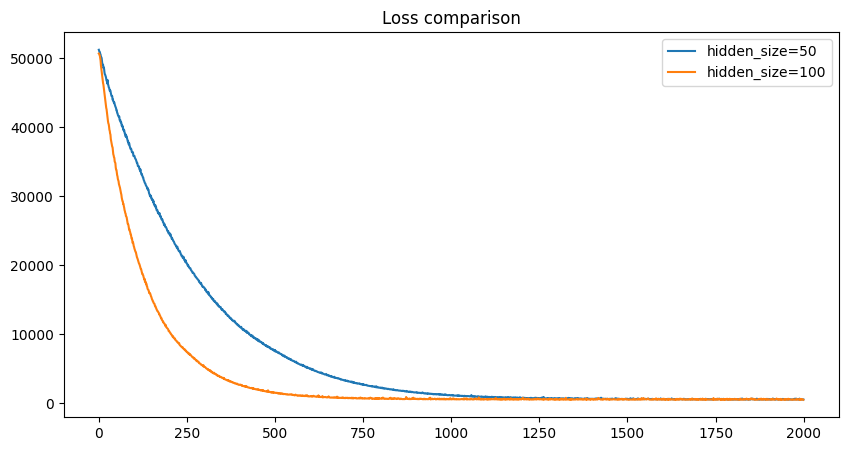

In [24]:
plt.figure(figsize=(10,5))

plt.plot(losses, label="hidden_size=50")
plt.plot(losses_100, label="hidden_size=100")

plt.legend()
plt.title("Loss comparison")
plt.show()

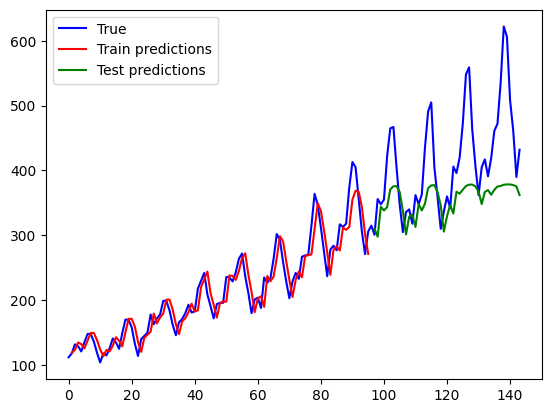

In [27]:
plot_predicts(passengers_np, model=model_100)
# plot_predicts(passengers_np, model=model)

model with more hidden size length is a bit better in training speed and validation dataset prediction metrics

# Loopbacks experiments

In [28]:
# Prepare datasets
lookbacks = [6, 12]

datasets = {}
loaders = {}

for lb in lookbacks:
    X_train, y_train = create_dataset(train_data, lookback=lb)
    X_val, y_val = create_dataset(val_data, lookback=lb)

    datasets[lb] = (X_train, y_train, X_val, y_val)

    train_dataset = TensorDataset(X_train, y_train)
    train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)

    loaders[lb] = train_loader

In [29]:
# new train function
def train_model(X_train, y_train, X_val, y_val, train_loader, lookback, hidden_size=100, lr=0.001):

    model = AirModel(hidden_size=hidden_size, num_layers=1)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    losses = []

    for epoch in range(2000):

        model.train()
        epoch_losses = []

        for X_batch, y_batch in train_loader:

            optimizer.zero_grad()

            preds = model(X_batch)
            loss = criterion(preds, y_batch)

            loss.backward()
            optimizer.step()

            epoch_losses.append(loss.item())

        losses.append(np.mean(epoch_losses))

        if epoch % 100 == 0:

            model.eval()
            with torch.no_grad():

                train_pred = model(X_train)
                val_pred = model(X_val)

                train_rmse = torch.sqrt(criterion(train_pred, y_train)).item()
                val_rmse = torch.sqrt(criterion(val_pred, y_val)).item()

            print(f"[lookback={lookback}] Epoch {epoch}: "
                  f"train RMSE {train_rmse:.4f}, val RMSE {val_rmse:.4f}")

    return model, losses

In [30]:
# Train both models
results = {}

for lb in lookbacks:

    X_train, y_train, X_val, y_val = datasets[lb]
    train_loader = loaders[lb]

    model, losses = train_model(
        X_train, y_train, X_val, y_val,
        train_loader, lb
    )

    results[lb] = {
        "model": model,
        "losses": losses,
        "data": (X_train, y_train, X_val, y_val)
    }

[lookback=6] Epoch 0: train RMSE 229.7455, val RMSE 428.9404
[lookback=6] Epoch 100: train RMSE 135.7821, val RMSE 328.6412
[lookback=6] Epoch 200: train RMSE 83.6705, val RMSE 263.1897
[lookback=6] Epoch 300: train RMSE 52.2623, val RMSE 211.7656
[lookback=6] Epoch 400: train RMSE 36.2902, val RMSE 175.7145
[lookback=6] Epoch 500: train RMSE 28.8001, val RMSE 149.9891
[lookback=6] Epoch 600: train RMSE 21.7253, val RMSE 130.1617
[lookback=6] Epoch 700: train RMSE 17.2593, val RMSE 114.7123
[lookback=6] Epoch 800: train RMSE 14.3451, val RMSE 105.5714
[lookback=6] Epoch 900: train RMSE 11.8578, val RMSE 99.2878
[lookback=6] Epoch 1000: train RMSE 10.7247, val RMSE 93.8323
[lookback=6] Epoch 1100: train RMSE 8.9205, val RMSE 90.9711
[lookback=6] Epoch 1200: train RMSE 7.8711, val RMSE 90.0238
[lookback=6] Epoch 1300: train RMSE 7.6577, val RMSE 89.6672
[lookback=6] Epoch 1400: train RMSE 5.9633, val RMSE 85.8216
[lookback=6] Epoch 1500: train RMSE 5.3008, val RMSE 84.9168
[lookback=6] E

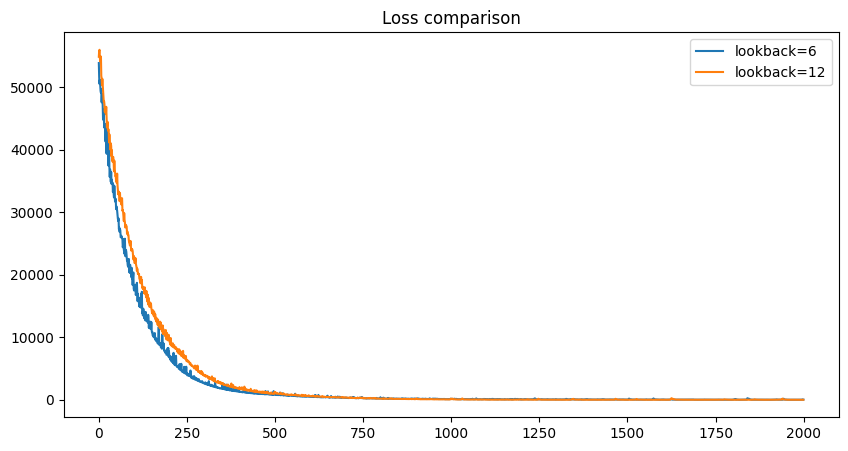

In [31]:
plt.figure(figsize=(10,5))

plt.plot(results[6]["losses"], label="lookback=6")
plt.plot(results[12]["losses"], label="lookback=12")

plt.title("Loss comparison")
plt.legend()
plt.show()

In [32]:
def plot_model(model, lookback):

    X_train, y_train, X_val, y_val = results[lookback]["data"]

    with torch.no_grad():

        timeseries = passengers_np

        train_pred = model(X_train)[:, -1].numpy().flatten()
        val_pred = model(X_val)[:, -1].numpy().flatten()

        train_plot = np.full_like(timeseries, np.nan, dtype=np.float32)
        val_plot = np.full_like(timeseries, np.nan, dtype=np.float32)

        train_plot[lookback:lookback+len(train_pred)] = train_pred

        test_start = train_size + lookback
        val_plot[test_start:test_start+len(val_pred)] = val_pred

    plt.figure(figsize=(12,5))
    plt.plot(timeseries, label="True")
    plt.plot(train_plot, label=f"Train (lb={lookback})")
    plt.plot(val_plot, label=f"Val (lb={lookback})")
    plt.legend()
    plt.show()

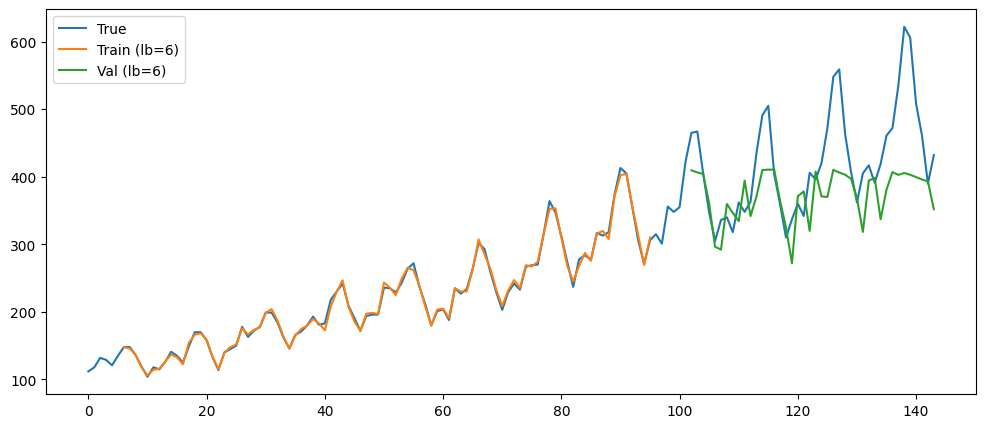

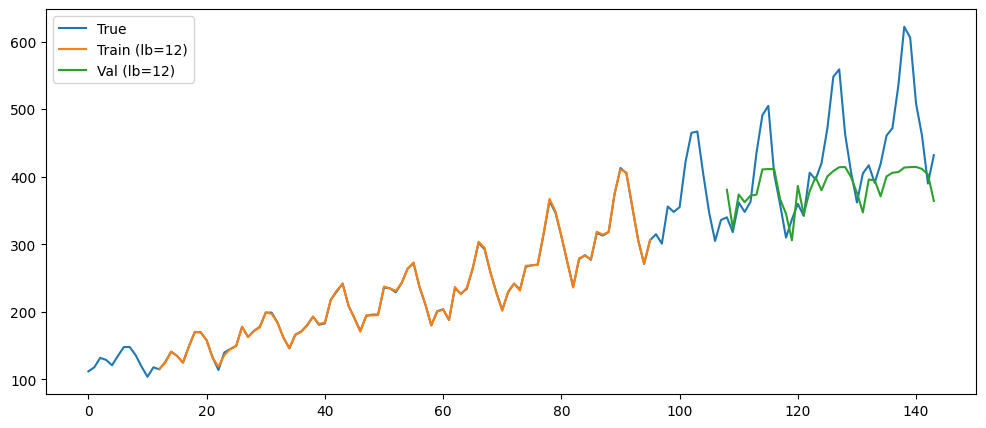

In [33]:
plot_model(results[6]["model"], 6)
plot_model(results[12]["model"], 12)